<a href="https://colab.research.google.com/github/Utsav248/Utsav_Jarga_Magar_2408957_AIML/blob/main/Worksheet4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [129]:
#import tensorflow as tf

#print(tf.keras.__version__)

In [130]:
#import numpy as np
#def f(x):
#  return x*82
#def gradient(x):
#  return 2 * x
#x = 5.0
#learning_rate = 0.1
#for _ in range(10):
#  x -= learning_rate * gradient(x)
#  print(f"z: {x}, f(x): {f(x)}")

In [131]:
#import tensorflow as tf
#x = tf.Variable(5.0)
#with tf.GradientTape() as tape:
#  y = x** 2
#grad = tape.gradient(y, x)
#print(grad.numpy())

In [132]:
#import numpy as np
#import tensorflow as tf
#import time

#size = (1000, 1000)
#A = np.random.rand(*size)
#B = np.random.rand(*size)

#start = time.time()
#C_numpy = np.dot(A, B)
#print("NumPy Time:", time.time() - start)

#A_tf = tf.constant(A)
#B_tf = tf.constant(B)
#tart = time.time()
#C_tf = tf.matmul(A_tf, B_tf)
#print("TensorFlow Time:", time.time() - start)

In [133]:
#from tensorflow.keras.layers import Dense
#layer = Dense(64, activation = 'sigmoid')

In [134]:
#import numpy as np

#for epoch in range(10):
#  y_pred = np.dot(x_train, weights)
#  lose = np.mean((y_pred - y_train) ** 2)
#  gradients = 2* np.dot(x_train.T, (y_pred - y_train))/ len(x_train)
#  weights -= learning_rate * gradients

In [135]:
# model.fit(x_train, y_train, epochs=10, batch_size=32)

In [136]:
#from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import Dense
#model = Sequential([
#    Dense(64, activation = 'relu', input_shape = (784,)),
#    Dense(10, activation = 'softmax')
#])

In [137]:
#learning_rate = 0.01
#weights = np.random.randn(3, 3)
#for _ in range(100):
#  gradient = np.random.randn(3, 3)
#  weights -= learning_rate * gradient

In [138]:
#from tensorflow.keras.optimizers import SGD
#optimizer = SGD(learning_rate = 0.01)

In [139]:
#from tensorflow.keras.layers import Dense
#units = 32 # Define units to fix the NameError
#layer = Dense(units, activation = None, use_bias = True, kernel_initializer = "glorot_uniform")

In [140]:
#from tensorflow.keras.layers import Dense
#layer = Dense(64, activation="sigmoid")

## Task 1: Data Preparation

This section loads and preprocesses the Devnagari digit dataset using PIL. It assumes the dataset is available in `dataset/Train` and `dataset/Test` directories, structured as `dataset/Train/digit_0/`, `dataset/Train/digit_1/`, etc.

In [141]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Training set: (5450, 28, 28, 1), labels: (5450, 10)
Testing set: (3000, 28, 28, 1), lables: (3000, 10)


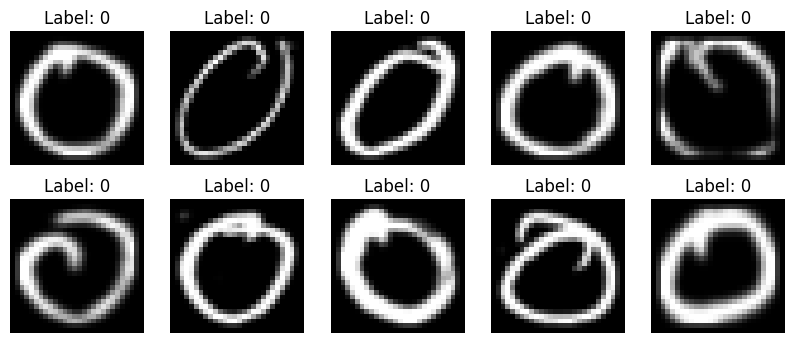

In [128]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image

#defining dayaset paths
train_dir = "/content/drive/MyDrive/Colab Notebooks/AIML/Dataset/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/Colab Notebooks/AIML/Dataset/DevanagariHandwrittenDigitDataset/Test"
img_height, img_width = 28, 28
#funciton to load images and labels using PIL
def load_images_from_folder(folder):
  images = []
  labels = []
  class_names = sorted(os.listdir(folder)) #sorted class names
  class_map = {name: i for i, name in enumerate(class_names)}
  for class_name in class_names:
    class_path = os.path.join(folder, class_name)
    label = class_map[class_name]
    for filename in os.listdir(class_path):
      img_path = os.path.join(class_path, filename)
      #loading image using PIL
      img = Image.open(img_path).convert("L") #convert to grayscale
      img = img.resize((img_width, img_height)) # resizing to (28,28)
      img = np.array(img) / 255.0
      images.append(img)
      labels.append(label)
  return np.array(images), np.array(labels)
#loading training and testing datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

#reshaping images for keras input
x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

#one-hot encode lables
y_train = to_categorical(y_train, num_classes = 10)
y_test = to_categorical(y_test, num_classes = 10)
#printing dataset shape
print(f"Training set: {x_train.shape}, labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, lables: {y_test.shape}")

plt.figure(figsize = (10,4))
for i in range(10):
  plt.subplot(2, 5, i + 1)
  plt.imshow(x_train[i].reshape(28,28), cmap = 'gray')
  plt.title(f"Label: {np.argmax(y_train[i])}")
  plt.axis("Off")
plt.show()

## Task 2: Build the FCN Model

We will create a Sequential model with three hidden `Dense` layers using `sigmoid` activation and an output `Dense` layer with `softmax` activation.

In [142]:
import tensorflow as tf
from tensorflow import keras
num_classes = 10
input_shape = (28, 28, 1)
def build_functional_model():
  inputs = keras.Input(shape=input_shape)
  x = keras.layers.Flatten()(inputs)
  x = keras.layers.Dense(64, activation="sigmoid")(x)
  x = keras.layers.Dense(128, activation="sigmoid")(x)
  x = keras.layers.Dense(256, activation="sigmoid")(x)
  outputs = keras.layers.Dense(num_classes, activation="softmax")(x)
  model = keras.Model(inputs=inputs, outputs=outputs)
  return model
#Building the model
functional_model = build_functional_model()
functional_model.summary()

Model: "functional_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

## Task 3: Compile the Model

We will compile the model using the `Adam` optimizer, `categorical_crossentropy` loss (since labels are one-hot encoded), and `accuracy` as a metric.

In [143]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer="Adam", # Using Adam optimizer as recommended
    loss="categorical_crossentropy", # Appropriate for one-hot encoded labels
    metrics=["accuracy"]
)

## Task 4: Train the Model

Train the model using `model.fit()` with a batch size of 128, 20 epochs, and a 20% validation split. Callbacks for `ModelCheckpoint` and `EarlyStopping` are included.

In [144]:
batch_size = 128 #number of training samples to process before updating models weight
epochs = 20

#Reshape x_train and x_test to match the model's expected input shape
x_train_reshaped = x_train.reshape(-1, 28, 28, 1)
x_test_reshaped = x_test.reshape(-1, 28, 28, 1)

#Re-define the model to ensure it's fresh for each run
import tensorflow as tf
from tensorflow import keras
num_classes = 10
input_shape = (28, 28, 1)
model = keras.Sequential([
    keras.layers.Input(shape=input_shape),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation="sigmoid"),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(256, activation="sigmoid"),
    keras.layers.Dense(num_classes, activation="softmax")
])

#Re-compile the model
model.compile( optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])

#callbacks
callbacks = [keras.callbacks.ModelCheckpoint(filepath="model_atepoch{epoch}.keras"), keras.callbacks.EarlyStopping(monitor="val_loss", patience=4)]
history = model.fit(
x_train_reshaped,
y_train,
batch_size=batch_size,
epochs=epochs,
validation_split=0.2,
callbacks=callbacks,)

Epoch 1/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.3592 - loss: 1.5987 - val_accuracy: 0.0000e+00 - val_loss: 2.5986
Epoch 2/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4007 - loss: 1.1451 - val_accuracy: 0.0000e+00 - val_loss: 2.6909
Epoch 3/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4140 - loss: 1.1086 - val_accuracy: 0.0000e+00 - val_loss: 2.9150
Epoch 4/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4073 - loss: 1.0956 - val_accuracy: 0.0000e+00 - val_loss: 2.9938
Epoch 5/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4080 - loss: 1.0871 - val_accuracy: 0.0000e+00 - val_loss: 2.9619


## Visualization of Training Progress

Plotting the training and validation loss and accuracy over epochs to visualize the model's learning curve.

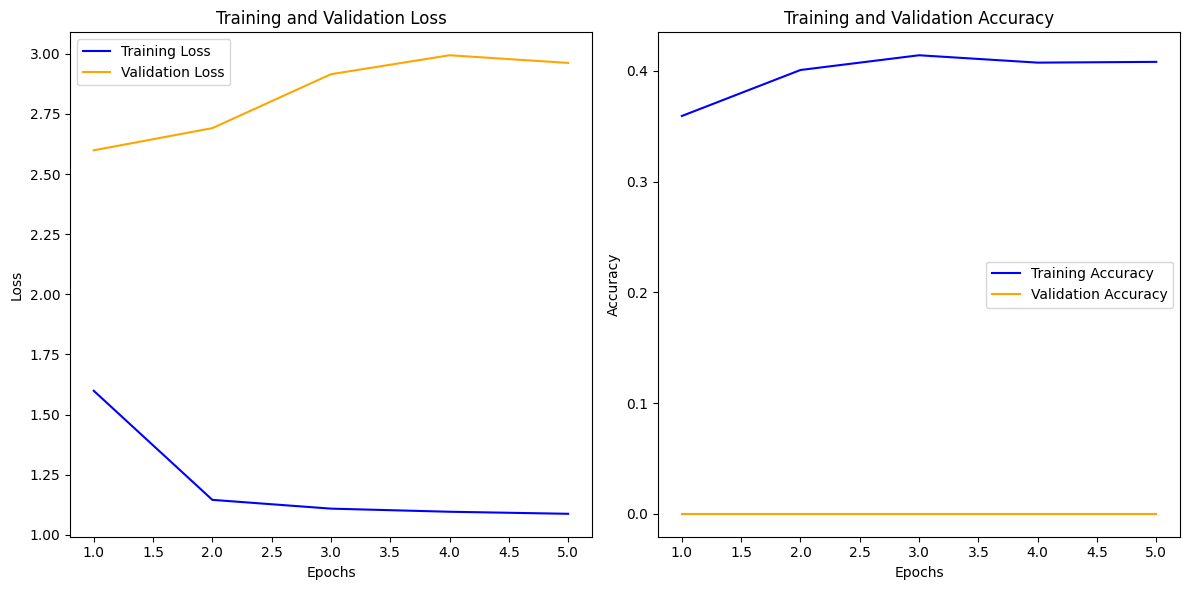

In [145]:
import matplotlib.pyplot as plt
# Assuming 'history' is the object returned by model.fit()
# Extracting training and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']
# Extracting training and validation accuracy (if metrics were specified)
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
# Plotting training and validation loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Training Loss', color='blue')
plt.plot(range(1, len(val_loss) + 1), val_loss, label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc) + 1), train_acc, label='Training Accuracy', color='blue')
plt.plot(range(1, len(val_acc) + 1), val_acc, label='Validation Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

## Task 5: Evaluate the Model

Evaluate the trained model on the unseen test set to determine its generalization performance.

In [146]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest accuracy: {test_acc:.4f}")

94/94 - 1s - 9ms/step - accuracy: 0.1000 - loss: 4.5094

Test accuracy: 0.1000


## Task 6: Save and Load the Model

Save the trained model to an `.h5` file and then load it back to demonstrate the saving/loading functionality.

In [147]:
import tensorflow as tf

# Assuming model_filename exists from previous steps (e.g., 'devnagari_fcn_model.keras')
model_filename = 'devnagari_fcn_model.keras' # Ensure this points to your saved model

# Load the model
loaded_model = tf.keras.models.load_model(model_filename)
print(f"Model loaded from {model_filename}")

# Evaluate the loaded model
test_loss, test_acc = loaded_model.evaluate(x_test_reshaped, y_test, verbose=2)
print(f"\nTest accuracy of loaded model: {test_acc:.4f}")

Model loaded from devnagari_fcn_model.keras
94/94 - 1s - 12ms/step - accuracy: 0.1000 - loss: 4.6002

Test accuracy of loaded model: 0.1000


## Task 7: Predictions

Use the trained model to make predictions on the test images and convert the probabilities to digit labels.

In [148]:
import numpy as np
import matplotlib.pyplot as plt

# Predict on test data using the loaded model
predictions = loaded_model.predict(x_test_reshaped)

# Convert predictions from probabilities to digit labels
predicted_labels = np.argmax(predictions, axis=1);

# Convert true labels back from one-hot encoding for comparison
true_labels = np.argmax(y_test, axis=1);

# Display some example predictions
print("\nExample Predictions:")
for i in range(5):
    print(f"Image {i+1}: Predicted Label = {predicted_labels[i]}, True Label = {true_labels[i]}")


94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

Example Predictions:
Image 1: Predicted Label = 1, True Label = 0
Image 2: Predicted Label = 1, True Label = 0
Image 3: Predicted Label = 1, True Label = 0
Image 4: Predicted Label = 1, True Label = 0
Image 5: Predicted Label = 1, True Label = 0
